# 作业B：NumPy二维卷积与向量化加速

本作业分别使用双重循环和 im2col + 矩阵乘法实现二维卷积，
验证两种实现的数值一致性，并比较运行速度。

In [3]:
import time

import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(
    precision=3,
    suppress=True
)

In [4]:
test_image = np.arange(
    1,
    26,
    dtype=np.float32
).reshape(5, 5)

mean_kernel = np.ones(
    (3, 3),
    dtype=np.float32
) / 9.0

print("测试图像：")
print(test_image)

print("\n3×3均值卷积核：")
print(mean_kernel)

测试图像：
[[ 1.  2.  3.  4.  5.]
 [ 6.  7.  8.  9. 10.]
 [11. 12. 13. 14. 15.]
 [16. 17. 18. 19. 20.]
 [21. 22. 23. 24. 25.]]

3×3均值卷积核：
[[0.111 0.111 0.111]
 [0.111 0.111 0.111]
 [0.111 0.111 0.111]]


In [6]:
def conv2d_naive(image, kernel):
    """使用双重循环实现二维卷积。"""

    image = np.asarray(
        image,
        dtype=np.float32
    )

    kernel = np.asarray(
        kernel,
        dtype=np.float32
    )

    # 获取卷积核尺寸
    kernel_height, kernel_width = kernel.shape

    # 计算上下、左右需要补多少像素
    pad_height = kernel_height // 2
    pad_width = kernel_width // 2

    # 在图像外围补0，使输出尺寸与输入一致
    padded_image = np.pad(
        image,
        (
            (pad_height, pad_height),
            (pad_width, pad_width)
        ),
        mode="constant"
    )

    # 数学卷积需要将卷积核上下、左右翻转
    flipped_kernel = np.flip(
        kernel,
        axis=(0, 1)
    )

    # 创建保存结果的数组
    output = np.zeros_like(
        image,
        dtype=np.float32
    )

    image_height, image_width = image.shape

    # 遍历图像中的每一个位置
    for row in range(image_height):
        for column in range(image_width):

            # 取出当前像素周围的局部区域
            region = padded_image[
                row:row + kernel_height,
                column:column + kernel_width
            ]

            # 对应位置相乘，然后全部求和
            output[row, column] = np.sum(
                region * flipped_kernel
            )

    return output

In [7]:
naive_result = conv2d_naive(
    test_image,
    mean_kernel
)

print("双重循环卷积结果：")
print(naive_result)

print("\n输入形状：", test_image.shape)
print("输出形状：", naive_result.shape)

双重循环卷积结果：
[[ 1.778  3.     3.667  4.333  3.111]
 [ 4.333  7.     8.     9.     6.333]
 [ 7.667 12.    13.    14.     9.667]
 [11.    17.    18.    19.    13.   ]
 [ 8.444 13.    13.667 14.333  9.778]]

输入形状： (5, 5)
输出形状： (5, 5)


In [8]:
def conv2d_im2col(image, kernel):
    """使用 im2col 和矩阵乘法实现二维卷积。"""

    image = np.asarray(
        image,
        dtype=np.float32
    )

    kernel = np.asarray(
        kernel,
        dtype=np.float32
    )

    kernel_height, kernel_width = kernel.shape

    pad_height = kernel_height // 2
    pad_width = kernel_width // 2

    # 图像外围补0
    padded_image = np.pad(
        image,
        (
            (pad_height, pad_height),
            (pad_width, pad_width)
        ),
        mode="constant"
    )

    # 一次性获得所有局部窗口
    windows = np.lib.stride_tricks.sliding_window_view(
        padded_image,
        (kernel_height, kernel_width)
    )

    # 每个3×3窗口展开成一行
    image_columns = windows.reshape(
        -1,
        kernel_height * kernel_width
    )

    # 翻转卷积核，并展开成一维向量
    kernel_vector = np.flip(
        kernel,
        axis=(0, 1)
    ).reshape(-1)

    # 矩阵乘法，一次得到所有位置的结果
    output_vector = (
        image_columns @ kernel_vector
    )

    # 将一维结果恢复为二维图像
    output = output_vector.reshape(
        image.shape
    )

    return output

In [9]:
padded_test_image = np.pad(
    test_image,
    ((1, 1), (1, 1)),
    mode="constant"
)

test_windows = np.lib.stride_tricks.sliding_window_view(
    padded_test_image,
    (3, 3)
)

test_columns = test_windows.reshape(
    -1,
    9
)

print("原始图像形状：", test_image.shape)
print("补零后形状：", padded_test_image.shape)
print("全部窗口形状：", test_windows.shape)
print("im2col矩阵形状：", test_columns.shape)

print("\nim2col矩阵的第一行：")
print(test_columns[0])

原始图像形状： (5, 5)
补零后形状： (7, 7)
全部窗口形状： (5, 5, 3, 3)
im2col矩阵形状： (25, 9)

im2col矩阵的第一行：
[0. 0. 0. 0. 1. 2. 0. 6. 7.]


In [10]:
im2col_result = conv2d_im2col(
    test_image,
    mean_kernel
)

print("im2col卷积结果：")
print(im2col_result)

print("\n两种结果是否一致：")
print(
    np.allclose(
        naive_result,
        im2col_result,
        atol=1e-6
    )
)

print("\n最大绝对误差：")
print(
    np.max(
        np.abs(
            naive_result - im2col_result
        )
    )
)

im2col卷积结果：
[[ 1.778  3.     3.667  4.333  3.111]
 [ 4.333  7.     8.     9.     6.333]
 [ 7.667 12.    13.    14.     9.667]
 [11.    17.    18.    19.    13.   ]
 [ 8.444 13.    13.667 14.333  9.778]]

两种结果是否一致：
True

最大绝对误差：
1.9073486e-06


In [11]:
rng = np.random.default_rng(seed=42)

benchmark_image = rng.random(
    (512, 512)
).astype(np.float32)

gaussian_kernel = np.array(
    [
        [1, 2, 1],
        [2, 4, 2],
        [1, 2, 1]
    ],
    dtype=np.float32
) / 16.0

print("测试图像形状：", benchmark_image.shape)
print("测试图像类型：", benchmark_image.dtype)

print("\n高斯卷积核：")
print(gaussian_kernel)

print("\n卷积核元素之和：")
print(gaussian_kernel.sum())

测试图像形状： (512, 512)
测试图像类型： float32

高斯卷积核：
[[0.062 0.125 0.062]
 [0.125 0.25  0.125]
 [0.062 0.125 0.062]]

卷积核元素之和：
1.0


In [12]:
small_image = benchmark_image[:32, :32]

_ = conv2d_naive(
    small_image,
    gaussian_kernel
)

_ = conv2d_im2col(
    small_image,
    gaussian_kernel
)

print("预热完成")

预热完成


In [13]:
start_time = time.perf_counter()

naive_large_result = conv2d_naive(
    benchmark_image,
    gaussian_kernel
)

naive_time = (
    time.perf_counter() - start_time
)

print(
    f"双重循环耗时：{naive_time:.6f} 秒"
)

双重循环耗时：0.801501 秒


In [14]:
start_time = time.perf_counter()

im2col_large_result = conv2d_im2col(
    benchmark_image,
    gaussian_kernel
)

im2col_time = (
    time.perf_counter() - start_time
)

print(
    f"im2col耗时：{im2col_time:.6f} 秒"
)

im2col耗时：0.005646 秒


In [15]:
results_match = np.allclose(
    naive_large_result,
    im2col_large_result,
    atol=1e-5
)

maximum_error = np.max(
    np.abs(
        naive_large_result
        - im2col_large_result
    )
)

speedup = naive_time / im2col_time

print("两种结果是否一致：", results_match)

print(
    f"最大绝对误差：{maximum_error:.8f}"
)

print(
    f"双重循环耗时：{naive_time:.6f} 秒"
)

print(
    f"im2col耗时：{im2col_time:.6f} 秒"
)

print(
    f"im2col加速倍数：{speedup:.2f} 倍"
)

两种结果是否一致： True
最大绝对误差：0.00000012
双重循环耗时：0.801501 秒
im2col耗时：0.005646 秒
im2col加速倍数：141.96 倍


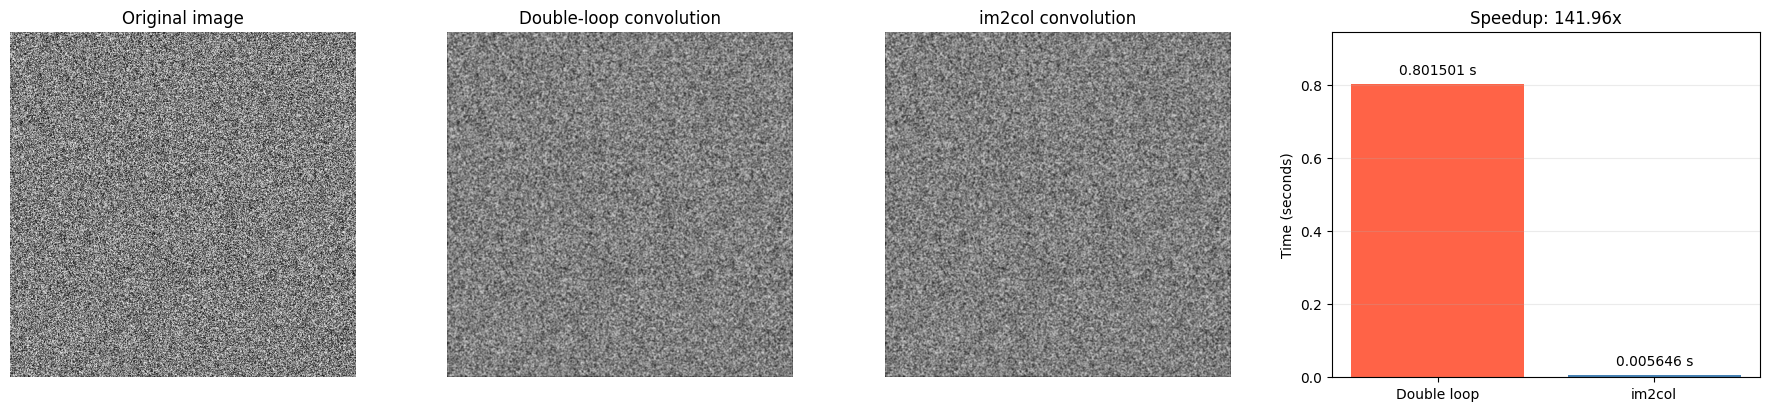

In [16]:
from pathlib import Path

fig, axes = plt.subplots(
    1,
    4,
    figsize=(18, 4),
    constrained_layout=True
)

# 原始随机图像
axes[0].imshow(
    benchmark_image,
    cmap="gray",
    vmin=0.0,
    vmax=1.0
)

axes[0].set_title("Original image")
axes[0].axis("off")

# 双重循环结果
axes[1].imshow(
    naive_large_result,
    cmap="gray",
    vmin=0.0,
    vmax=1.0
)

axes[1].set_title("Double-loop convolution")
axes[1].axis("off")

# im2col结果
axes[2].imshow(
    im2col_large_result,
    cmap="gray",
    vmin=0.0,
    vmax=1.0
)

axes[2].set_title("im2col convolution")
axes[2].axis("off")

# 运行时间柱状图
method_names = [
    "Double loop",
    "im2col"
]

method_times = [
    naive_time,
    im2col_time
]

bars = axes[3].bar(
    method_names,
    method_times,
    color=["tomato", "steelblue"]
)

axes[3].set_title(
    f"Speedup: {speedup:.2f}x"
)

axes[3].set_ylabel("Time (seconds)")
axes[3].grid(
    axis="y",
    alpha=0.25
)

axes[3].set_ylim(
    0,
    naive_time * 1.18
)

# 在柱子上标出具体时间
for bar, current_time in zip(
    bars,
    method_times
):
    axes[3].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + naive_time * 0.025,
        f"{current_time:.6f} s",
        ha="center",
        va="bottom"
    )

In [17]:
output_dir = Path(
    r"C:\Users\ET\projects\dl-learning-journey"
) / "assignments" / "03_numpy_convolution" / "outputs"

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

output_path = (
    output_dir
    / "convolution_speed_comparison.png"
)

fig.savefig(
    output_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("结果图已保存：")
print(output_path)

print("\n文件是否存在：")
print(output_path.exists())

结果图已保存：
C:\Users\ET\projects\dl-learning-journey\assignments\03_numpy_convolution\outputs\convolution_speed_comparison.png

文件是否存在：
True


## 实验结论

本实验分别使用双重循环和 im2col + 矩阵乘法实现了二维卷积。

在大小为 512×512 的 float32 图像上，双重循环耗时约为
0.801501 秒，im2col 方法耗时约为 0.005646 秒，向量化方法
加速约 141.96 倍。

两种方法的计算结果通过 `np.allclose` 检验，最大绝对误差约为
1.2×10⁻⁷。该误差来自 float32 浮点数的舍入，不影响结果的一致性。

实验说明，向量化没有改变卷积的数学含义，而是将大量 Python
循环转换为 NumPy 底层的矩阵运算，从而显著提高计算速度。